# 72-hour SHARP forecast-state decisions
**Notebook 05 · Bamidele Akinwumi · exploratory research prototype**

## tl;dr
**The candidate logistic fallback is not ready for adoption.** It restores some flare alerts but makes incorrect decisions on about half of its routed cases. GRU-only guards reduce observed error among issued decisions while deferring more than half of flare windows. These findings do not establish an acceptable operational policy.

| Evaluation period | Ungated singleton error | Guarded GRU error | Guarded GRU: flare windows deferred | Fallback-only error |
|---|---:|---:|---:|---:|
| 2021–2025 | 16.9% | 12.8% | 53.3% | 49.2% (1,098/2,233) |
| 2026 (partial) | 17.0% | 15.7% | 53.5% | 46.4% (217/468) |

Results above use the parent **90% conformal target**, not a promised accuracy for issued forecasts. State names are experimental. All counts refer to forecast windows, not independent flare events. The saved notebook includes both 90% and 95% comparisons, three figures, all declared sensitivities and complete-population availability.

## Context & Methods

The uncertainty experiment improved flare inclusion by retaining both possible outcomes more often. Here we test a decision layer on the **same frozen GRU ensemble and logistic model**, using the previously selected **180-day rolling class-conditional sets**. There is no new backbone training or AIA download.

| Candidate state | Rule | Issued output |
|---|---|---|
| Normal | Valid assembled inputs; both calibration classes supported; GRU singleton; feature distance and seed spread within earlier-reference limits; no opposite logistic singleton | GRU probability and the singleton label |
| Degraded | Shared checks pass; GRU has both labels or excessive seed spread; logistic has its own supported singleton; no contradictory GRU singleton | Logistic probability and its singleton label; candidate fallback recorded |
| Abstain | Missing/invalid input, unavailable set, insufficient support, unusual feature distance, contradictory singletons, empty GRU set, or no eligible mode | No issued probability or binary decision; audit scores remain available |

The comparison includes ungated GRU singletons, support-gated GRU singletons, the full guards without fallback, and the full guards with fallback. These are declared ablations. A singleton's label determines the issued decision; this is not necessarily the same as thresholding its probability at 0.5.

### Key Assumptions

- The primary feature-distance limit is the **99th percentile** and seed-spread limit the **95th percentile**, measured on January–June 2014. Limits are heuristics fixed before this evaluation, not optimized on later labels or tied to an agreed acceptable-error target.
- Fit a Ledoit–Wolf covariance on flattened training histories from **2010–2013**, after the original signed-log standardization. Squared Mahalanobis distance measures deviation from that reference; it is not proof that a case is out of distribution. Three-seed probability standard deviation measures disagreement, not a calibrated uncertainty interval.
- The 2014 reference block already informed model early stopping. The 2015–2019 development block already selected rolling windows. Reuse is disclosed; none is fresh independent validation.
- Evaluate nominal conformal levels 90% and 95%. These are **parent set targets**, not accuracies promised for selected singletons. Rejecting cases does not preserve a conformal coverage guarantee.
- The same SHARP inputs support both models. The logistic fallback cannot repair missing SHARP, unusual shared features or source outages. It is a research candidate, not an approved reduced-input mode.
- Labels are provisional M/X-start-within-72-hour outcomes. Windows overlap. Unknown labels never count as negatives; missing inputs and unknown outcomes remain in full-population reporting.
- Historical delivery and source quality remain unverified; the parent replay assumes a 24-hour label delay after complete follow-up. Input-contract checks cover assembled finite histories and timestamp order, not all instrument quality conditions.
- All later years have already been inspected. This is exploratory retrospective work. Conditional group-bootstrap intervals do not include repeated gate fitting, sequential adaptation, selection or label uncertainty.

Selective error means **incorrect issued decisions / all issued decisions**. Retention means **issued decisions / evaluated windows**, distinct from conformal set coverage. Also report class-specific retention and the partition of all flare windows into alerts, false clears and deferrals. A low overall error can hide an unacceptable number of missed or deferred flares.

Primary methodological context: [Geifman & El-Yaniv, selective classification](https://papers.neurips.cc/paper_files/paper/2017/hash/4a8423d5e91fda00bb7e46540e2b0cf1-Abstract.html) motivates the risk–retention tradeoff; this notebook does not implement its risk certificate. [Ledoit–Wolf implementation](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html) provides shrinkage covariance and squared distances.

## Data
### 1. Environment and configuration
Use the existing training kernel and `requirements-notebook.txt`. All functions are embedded; no repository Python imports or cloud access are required. Exact parent files remain local and are verified by hashes.

In [1]:
from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import sklearn
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
WORKSPACE=Path.cwd()
if WORKSPACE.name=='notebooks':WORKSPACE=WORKSPACE.parent
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':115,'axes.titleweight':'bold'})
PERIODS={'policy_validation':'2015–2019 development (reused)','retrospective_cycle25':'2021–2025','supplementary_2026':'2026 (partial)'}
print({'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__})

{'numpy': '2.3.5', 'pandas': '2.2.3', 'sklearn': '1.7.2'}


In [2]:
CONFIG=json.loads(r'''{
  "experiment": "sharp72_decision_policy_candidate_v1",
  "dataset": "data/processed/training_snapshot_20261002/gray_box_aligned_v1",
  "dataset_manifest_sha256": "7bb88614482cacd5fafb145d88345132a6cf97b25b8313dbefd90b08ac5b9d27",
  "training_dir": "outputs/sharp72_notebook_v1_20261002T080801721986Z",
  "training_summary_sha256": "e6418e5aac60a4ef7641ff32cd5c1b1b282db1e2b88af0a6f6aebc79a62058d0",
  "rolling_dir": "outputs/sharp72_rolling_v1_20261002T100951575030Z",
  "rolling_summary_sha256": "28f744f50a476b2950bc299487d754101cb96c588d8723a25d832f1d69dd5f6d",
  "alphas": [
    0.1,
    0.05
  ],
  "primary_alpha": 0.1,
  "feature_distance": "Squared Mahalanobis distance, Ledoit-Wolf covariance fitted on 2010-2013 training cases, original signed-log standardization, flattened 3x16 histories",
  "threshold_reference_role": "model_validation",
  "threshold_reference_period": "January-June 2014; already used for backbone early stopping; no outcome-based gate selection",
  "quantile_method": "higher",
  "primary_policy": "guarded_fallback",
  "policy_selection": "No later-outcome selection. Primary gates fixed at feature-distance q99 and seed-spread q95; other pairs are declared sensitivity checks.",
  "policies": [
    {
      "name": "gru_singleton",
      "support": false,
      "conflict": false,
      "fallback": false,
      "distance_quantile": null,
      "spread_quantile": null
    },
    {
      "name": "supported_gru",
      "support": true,
      "conflict": false,
      "fallback": false,
      "distance_quantile": null,
      "spread_quantile": null
    },
    {
      "name": "guarded_gru",
      "support": true,
      "conflict": true,
      "fallback": false,
      "distance_quantile": 0.99,
      "spread_quantile": 0.95
    },
    {
      "name": "guarded_fallback",
      "support": true,
      "conflict": true,
      "fallback": true,
      "distance_quantile": 0.99,
      "spread_quantile": 0.95
    },
    {
      "name": "fallback_q95_q90",
      "support": true,
      "conflict": true,
      "fallback": true,
      "distance_quantile": 0.95,
      "spread_quantile": 0.9
    },
    {
      "name": "fallback_q975_q95",
      "support": true,
      "conflict": true,
      "fallback": true,
      "distance_quantile": 0.975,
      "spread_quantile": 0.95
    },
    {
      "name": "fallback_q995_q975",
      "support": true,
      "conflict": true,
      "fallback": true,
      "distance_quantile": 0.995,
      "spread_quantile": 0.975
    },
    {
      "name": "fallback_q100_q99",
      "support": true,
      "conflict": true,
      "fallback": true,
      "distance_quantile": 1.0,
      "spread_quantile": 0.99
    }
  ],
  "evaluation_roles": [
    "policy_validation",
    "retrospective_cycle25",
    "supplementary_2026"
  ],
  "bootstrap_repetitions": 1000,
  "bootstrap_seed": 24680,
  "bootstrap_scope": "Conditional on realized state decisions; region-component and 7-day UTC blocks; adaptation and policy development are not rerun",
  "policy_status": "research_prototype_not_operationally_validated"
}''')
OUTPUT_DIR=WORKSPACE/'outputs'/('sharp72_policy_v1_'+datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
print('New run:',OUTPUT_DIR)
display(pd.DataFrame(CONFIG['policies']))

New run: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_policy_v1_20261002T110739251629Z


,name,support,conflict,fallback,distance_quantile,spread_quantile
0,gru_singleton,False,False,False,NaN,NaN
1,supported_gru,True,False,False,NaN,NaN
2,guarded_gru,True,True,False,0.990,0.950
3,guarded_fallback,True,True,True,0.990,0.950
4,fallback_q95_q90,True,True,True,0.950,0.900
5,fallback_q975_q95,True,True,True,0.975,0.950
6,fallback_q995_q975,True,True,True,0.995,0.975
7,fallback_q100_q99,True,True,True,1.000,0.990


### 2. Verify sources and fit earlier reference checks
Only 2010–2013 training cases fit the covariance. The 2014 reference inputs set gate quantiles without reading their outcome values for threshold selection. Later cases do not change these frozen limits.

In [3]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def save_json(path, value):
    path.write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')

def checked_parent(path, expected):
    if sha256(path / 'summary.json') != expected:
        raise ValueError('Parent summary changed')
    summary = json.loads((path / 'summary.json').read_text())
    for name, digest in summary['output_sha256'].items():
        if sha256(path / name) != digest:
            raise ValueError(f'Parent output changed: {name}')
    return summary

def gate_threshold(values, quantile):
    if quantile is None:
        return None
    x = np.asarray(values, dtype=float)
    if not 0 < quantile <= 1 or x.ndim != 1 or not len(x) or not np.isfinite(x).all():
        raise ValueError('Invalid reference values or quantile')
    return float(np.quantile(x, quantile, method='higher'))

def load_policy_inputs(root, config):
    training = root / config['training_dir']
    rolling = root / config['rolling_dir']
    dataset = root / config['dataset']
    train_summary = checked_parent(training, config['training_summary_sha256'])
    roll_summary = checked_parent(rolling, config['rolling_summary_sha256'])
    if train_summary['horizon'] != 72 or train_summary['scope'] != 'primary':
        raise ValueError('Wrong target')
    if sha256(dataset / 'manifest.json') != config['dataset_manifest_sha256']:
        raise ValueError('Dataset manifest changed')
    manifest = json.loads((dataset / 'manifest.json').read_text())
    for name in ['sharp.npy', 'input_index.csv.gz', 'master_cases.csv.gz']:
        if sha256(dataset / name) != manifest['outputs'][name]['sha256']:
            raise ValueError(f'Dataset input changed: {name}')
    frame = pd.read_csv(rolling / 'population_sets.csv.gz')
    predictions = pd.read_csv(training / 'predictions.csv.gz')
    index = pd.read_csv(dataset / 'input_index.csv.gz')
    master = pd.read_csv(dataset / 'master_cases.csv.gz', low_memory=False)
    raw = np.load(dataset / 'sharp.npy', allow_pickle=False)
    if frame.forecast_case_id.duplicated().any() or set(frame.forecast_case_id) != set(master.forecast_case_id):
        raise ValueError('Population mismatch')
    indexed = index.set_index('forecast_case_id').loc[predictions.forecast_case_id]
    if not np.array_equal(indexed.tensor_row, predictions.tensor_row) or not np.array_equal(index.tensor_row, np.arange(len(raw))):
        raise ValueError('Tensor identity mismatch')
    if not np.isfinite(raw).all():
        raise ValueError('Pinned assembled SHARP contains nonfinite data')
    seed_cols = ['probability_seed_17', 'probability_seed_29', 'probability_seed_43']
    seeds = predictions[seed_cols].to_numpy()
    if not np.isfinite(seeds).all() or ((seeds < 0) | (seeds > 1)).any():
        raise ValueError('Invalid seed probabilities')
    predictions['seed_spread'] = seeds.std(axis=1, ddof=0)
    for col in ['issue_utc', 'region_component_id', 'role']:
        aligned = frame.set_index('forecast_case_id').loc[predictions.forecast_case_id, col]
        if not np.array_equal(aligned.to_numpy(), predictions[col].to_numpy()):
            raise ValueError(f'Frozen identity changed: {col}')
    # The pinned probability-selection experiment retained raw values for both models.
    for selected, source in [('gru_selected', 'probability_gru_mean'), ('logistic_selected', 'probability_logistic')]:
        aligned = frame.set_index('forecast_case_id').loc[predictions.forecast_case_id, selected]
        if not np.allclose(aligned, predictions[source], rtol=0, atol=1e-14):
            raise ValueError('Selected probabilities no longer match raw parent')
    with np.load(training / 'transform.npz', allow_pickle=False) as t:
        normalized = ((np.sign(raw) * np.log1p(np.abs(raw)) - t['mean']) / t['std']).astype(np.float32)
    x = normalized[predictions.tensor_row.to_numpy()].reshape(len(predictions), -1).astype(float)
    fit = predictions.role.eq('train').to_numpy()
    reference = predictions.role.eq(config['threshold_reference_role']).to_numpy()
    dates = pd.to_datetime(predictions.issue_utc, utc=True)
    if not fit.any() or not reference.any() or (dates[fit] >= pd.Timestamp('2014-01-01', tz='UTC')).any() or ((dates[reference] < pd.Timestamp('2014-01-01', tz='UTC')) | (dates[reference] >= pd.Timestamp('2014-07-01', tz='UTC'))).any():
        raise ValueError('Gate fitting/reference periods are invalid')
    estimator = LedoitWolf().fit(x[fit])
    predictions['feature_distance_squared'] = estimator.mahalanobis(x)
    timing = indexed.reset_index()
    times = [pd.to_datetime(timing[c], utc=True) for c in ['history_288_UTC','history_192_UTC','history_96_UTC']]
    issues = pd.to_datetime(predictions.issue_utc, utc=True)
    predictions['input_contract_ok'] = ((times[0] < times[1]) & (times[1] < times[2]) & (times[2] < issues)).to_numpy()
    frame = frame.merge(predictions[['forecast_case_id','seed_spread','feature_distance_squared','input_contract_ok']], on='forecast_case_id', how='left', validate='one_to_one')
    frame['input_contract_ok'] = frame.input_contract_ok.eq(True)
    frame = frame.merge(master[['forecast_case_id','outcome_end_utc_72h']], on='forecast_case_id', validate='one_to_one')
    truth = master.set_index('forecast_case_id').loc[frame.forecast_case_id]
    if not np.array_equal(frame.candidate_primary_label_72h.fillna(-1), truth.candidate_primary_label_72h.fillna(-1)) or not np.array_equal(frame.label_known_primary_72h, frame.candidate_primary_label_72h.isin([0,1])):
        raise ValueError('Outcome mismatch')
    gates = {'fit_cases': int(fit.sum()), 'reference_cases': int(reference.sum()),
        'fit_case_ids_sha256': hashlib.sha256('\n'.join(sorted(predictions.loc[fit,'forecast_case_id'])).encode()).hexdigest(),
        'reference_case_ids_sha256': hashlib.sha256('\n'.join(sorted(predictions.loc[reference,'forecast_case_id'])).encode()).hexdigest(),
        'covariance_shrinkage': float(estimator.shrinkage_), 'selected_rolling_methods': roll_summary['selected_methods'], 'policies': {}}
    for policy in config['policies']:
        gates['policies'][policy['name']] = {
            'distance': gate_threshold(predictions.loc[reference,'feature_distance_squared'], policy['distance_quantile']),
            'spread': gate_threshold(predictions.loc[reference,'seed_spread'], policy['spread_quantile'])}
    return frame, gates, {'location': estimator.location_, 'precision': estimator.precision_}

### 3. Assign states without reading outcomes
The state function reads only scores, prediction sets, support and input checks. Its tests cover missing versus empty sets, conflicts, boundaries, invalid input, fallback restrictions and independence from current labels.

In [4]:
def decide_states(frame, gru_codes, logistic_codes, gru_guards, logistic_guards, policy, thresholds):
    """No labels are read. Null codes are unavailable, not empty sets."""
    g = np.asarray(gru_codes, dtype=float)
    l = np.asarray(logistic_codes, dtype=float)
    gg = np.asarray(gru_guards, dtype=float)
    lg = np.asarray(logistic_guards, dtype=float)
    for values in [g,l,gg,lg]:
        if len(values) != len(frame) or not np.isin(values[np.isfinite(values)], [0,1,2,3]).all():
            raise ValueError('Invalid set or support code')
    p = frame.gru_selected.to_numpy(dtype=float)
    lp = frame.logistic_selected.to_numpy(dtype=float)
    distance = frame.feature_distance_squared.to_numpy(dtype=float)
    spread = frame.seed_spread.to_numpy(dtype=float)
    valid_p = np.isfinite(p) & (p >= 0) & (p <= 1)
    valid_lp = np.isfinite(lp) & (lp >= 0) & (lp <= 1)
    inputs = frame.input_contract_ok.to_numpy(dtype=bool) & valid_p & np.isfinite(distance) & (distance >= 0) & np.isfinite(spread) & (spread >= 0)
    active = np.isfinite(g)
    gs = np.isin(g,[1,2]); ls = np.isin(l,[1,2])
    support_ok = gg == 0 if policy['support'] else np.ones(len(g),dtype=bool)
    fallback_support = lg == 0
    ood = (distance > thresholds['distance']) if thresholds['distance'] is not None else np.zeros(len(g),dtype=bool)
    unstable = (spread > thresholds['spread']) if thresholds['spread'] is not None else np.zeros(len(g),dtype=bool)
    conflict = gs & ls & (g != l) if policy['conflict'] else np.zeros(len(g),dtype=bool)
    ready = inputs & active & support_ok & ~ood & ~conflict
    normal = ready & gs & ~unstable
    # Empty GRU sets are unresolved contradictions. Both-label sets or high seed
    # spread may route to a supported logistic singleton, never through a shared OOD failure.
    degraded = ready & ~normal & (g != 0) & ls & fallback_support & valid_lp if policy['fallback'] else np.zeros(len(g),dtype=bool)
    state = np.select([normal,degraded], ['normal','degraded'], default='abstain')
    decision = np.where(normal,g-1,np.where(degraded,l-1,np.nan))
    probability = np.where(normal,p,np.where(degraded,lp,np.nan))
    reason = np.select([~inputs,~active,~support_ok,ood,conflict,g==0,normal,degraded,unstable,g==3],
        ['missing_or_invalid_input','no_issued_set','insufficient_calibration_support','feature_distance_flag','conflicting_singletons','empty_gru_set','checks_passed','logistic_fallback_candidate','seed_disagreement','ambiguous_gru_set'],default='no_supported_mode')
    return pd.DataFrame({'state':state,'decision':decision,'issued_probability':probability,
        'mode':np.select([normal,degraded],['gru','logistic'],default='none'),'reason':reason,
        'feature_flag':ood,'spread_flag':unstable,'conflicting_singletons':conflict,'support_ok':support_ok})

### 4. Count errors and deferrals with explicit denominators
Use 1,000 region-component resamples and 1,000 seven-day UTC block resamples as conditional sensitivities. They resample realized decisions, not the full adaptive training/calibration procedure.

In [5]:
RATE_DEFINITIONS = {'retention':('issued','cases'),'selective_error':('errors','issued'),
 'flare_retention':('flare_issued','flare_cases'),'nonflare_retention':('nonflare_issued','nonflare_cases'),
 'alert_fraction_of_all_flares':('true_alerts','flare_cases'),
 'false_clear_fraction_of_all_flares':('false_clears','flare_cases'),
 'deferred_fraction_of_all_flares':('deferred_flares','flare_cases'),
 'false_alert_fraction_of_all_nonflares':('false_alerts','nonflare_cases'),
 'false_clear_rate_among_retained_flares':('false_clears','flare_issued'),
 'false_alert_rate_among_retained_nonflares':('false_alerts','nonflare_issued')}

def decision_counts(y, decision):
    y=np.asarray(y); d=np.asarray(decision,dtype=float)
    if not np.isin(y,[0,1]).all() or not np.isin(d[np.isfinite(d)],[0,1]).all():
        raise ValueError('Metrics require known binary outcomes and valid decisions')
    issued=np.isfinite(d); flare=y==1; quiet=y==0
    return {'cases':len(y),'issued':int(issued.sum()),'errors':int((issued&(d!=y)).sum()),
      'flare_cases':int(flare.sum()),'nonflare_cases':int(quiet.sum()),
      'flare_issued':int((flare&issued).sum()),'nonflare_issued':int((quiet&issued).sum()),
      'true_alerts':int((flare&(d==1)).sum()),'false_clears':int((flare&(d==0)).sum()),
      'deferred_flares':int((flare&~issued).sum()),'false_alerts':int((quiet&(d==1)).sum()),
      'true_clears':int((quiet&(d==0)).sum()),'deferred_nonflares':int((quiet&~issued).sum())}

def decision_metrics(y, decision):
    c=decision_counts(y,decision)
    return {**c, **{name:c[num]/c[den] if c[den] else None for name,(num,den) in RATE_DEFINITIONS.items()}}

def decision_intervals(y, decision, groups, config):
    groups=np.asarray(groups)
    if pd.isna(groups).any() or len(groups)!=len(y):raise ValueError('Invalid resampling groups')
    table=pd.DataFrame({'y':np.asarray(y),'d':np.asarray(decision,dtype=float),'group':groups})
    counts=pd.DataFrame([decision_counts(b.y,b.d) for _,b in table.groupby('group',sort=True)])
    n=len(counts)
    if not n:return []
    weights=np.random.default_rng(config['bootstrap_seed']).multinomial(n,np.full(n,1/n),size=config['bootstrap_repetitions'])
    draws=dict(zip(counts.columns,(weights@counts.to_numpy()).T))
    rows=[]
    for metric,(num,den) in RATE_DEFINITIONS.items():
        valid=draws[den]>0; support=int(counts[den].gt(0).sum())
        low,high=np.quantile(draws[num][valid]/draws[den][valid],[.025,.975]) if support>=2 and valid.mean()>=.95 else [None,None]
        rows.append({'metric':metric,'low':float(low) if low is not None else None,'high':float(high) if high is not None else None,'groups':n,'groups_with_denominator':support,'valid_repetitions':int(valid.sum())})
    return rows

def run_policy(root, config, output, source_code):
    if output.exists():raise ValueError('Frozen output cannot be overwritten')
    frame,gates,estimator=load_policy_inputs(root,config)
    output.parent.mkdir(exist_ok=True,parents=True)
    staging=Path(tempfile.mkdtemp(prefix=output.name+'.incomplete-',dir=output.parent))
    try:
        save_json(staging/'protocol_before_evaluation.json',{'config':config,'recorded_utc':datetime.now(timezone.utc).isoformat()})
        save_json(staging/'frozen_gates.json',gates)
        np.savez(staging/'feature_distance_model.npz',**estimator)
        metrics=[]; states=[]; intervals=[]; yearly=[]; reasons=[]; availability=[]; decision_columns={}
        issues=pd.to_datetime(frame.issue_utc,utc=True)
        ready=pd.to_datetime(frame.outcome_end_utc_72h,utc=True)+pd.Timedelta(hours=24)
        scored=frame[['forecast_case_id','issue_utc','role','region_component_id','inputs_available','candidate_primary_label_72h','label_known_primary_72h','gru_selected','logistic_selected','seed_spread','feature_distance_squared','input_contract_ok']].copy()
        for alpha in config['alphas']:
            ac=str(alpha).replace('.','p')
            chosen=gates['selected_rolling_methods']
            cols=[f'{m}_{chosen[m]}_alpha{ac}' for m in ['gru','logistic']]
            guards=[f'{m}_{chosen[m]}_guard' for m in ['gru','logistic']]
            if any(c not in frame for c in cols+guards):raise ValueError('Pinned method is not a supported rolling policy')
            for policy in config['policies']:
                name=policy['name'];tags={'policy':name,'alpha':alpha}
                out=decide_states(frame,frame[cols[0]],frame[cols[1]],frame[guards[0]],frame[guards[1]],policy,gates['policies'][name])
                for col in ['state','decision','issued_probability','mode','reason']:
                    decision_columns[f'{name}_alpha{ac}_{col}']=out[col]
                if name==config['primary_policy']:
                    for col in ['feature_flag','spread_flag','conflicting_singletons','support_ok']:decision_columns[f'primary_alpha{ac}_{col}']=out[col]
                for role in config['evaluation_roles']:
                    mask=frame.role.eq(role)&frame.label_known_primary_72h
                    b=frame.loc[mask];o=out.loc[mask];y=b.candidate_primary_label_72h.to_numpy(dtype=int)
                    metrics.append({**tags,'role':role,**decision_metrics(y,o.decision)})
                    for state in ['normal','degraded','abstain']:
                        s=o.state.eq(state).to_numpy()
                        states.append({**tags,'role':role,'state':state,**decision_metrics(y[s],o.loc[s,'decision'])})
                    if name in ['gru_singleton','guarded_gru','guarded_fallback']:
                        for grouping in ['region_component','calendar_7day_UTC']:
                            groups=b.region_component_id.to_numpy() if grouping=='region_component' else (issues[mask].astype('int64')//(7*86400*10**9)).to_numpy()
                            for row in decision_intervals(y,o.decision,groups,config):intervals.append({**tags,'role':role,'grouping':grouping,**row})
                    if name in ['gru_singleton','guarded_fallback']:
                        for year in sorted(issues[mask].dt.year.unique()):
                            s=issues[mask].dt.year.eq(year).to_numpy()
                            yearly.append({**tags,'role':role,'year':int(year),**decision_metrics(y[s],o.loc[s,'decision'])})
                    if name==config['primary_policy']:
                        for reason,block in o.groupby('reason'):
                            reasons.append({**tags,'role':role,'reason':reason,'cases':len(block),'flare_cases':int(frame.loc[block.index,'candidate_primary_label_72h'].eq(1).sum())})
                if name==config['primary_policy']:
                    for year in sorted(issues.dt.year.unique()):
                        if year<2021:continue
                        # Preserve the calendar population, including missing/unknown cases.
                        mask=issues.dt.year.eq(year);o=out.loc[mask];b=frame.loc[mask]
                        availability.append({**tags,'year':int(year),'population_cases':int(mask.sum()),'known_outcomes':int(b.label_known_primary_72h.sum()),
                           'missing_inputs':int((~b.input_contract_ok).sum()),
                           'normal':int(o.state.eq('normal').sum()),'degraded':int(o.state.eq('degraded').sum()),'abstain':int(o.state.eq('abstain').sum()),
                           'issued_unknown_outcomes':int((o.decision.notna()&~b.label_known_primary_72h).sum()),
                           'known_flares':int(b.candidate_primary_label_72h.eq(1).sum()),
                           'deferred_known_flares':int((b.candidate_primary_label_72h.eq(1)&o.decision.isna()).sum()),
                           'boundary_unmatured_by_year_end':int((ready[mask]>pd.Timestamp(f'{year+1}-01-01',tz='UTC')).sum())})
        for name,rows in [('metrics',metrics),('state_metrics',states),('intervals',intervals),('yearly_metrics',yearly),('reason_counts',reasons),('availability',availability)]:
            pd.DataFrame(rows).to_csv(staging/f'{name}.csv',index=False)
        scored=pd.concat([scored,pd.DataFrame(decision_columns)],axis=1)
        scored.to_csv(staging/'population_decisions.csv.gz',index=False,compression={'method':'gzip','mtime':0})
        (staging/'executed_policy_code.py').write_text(source_code)
        save_json(staging/'run_contract.json',{'config':config,'versions':{'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__},'source_code_sha256':hashlib.sha256(source_code.encode()).hexdigest(),
          'state_semantics':{'normal':'Research candidate: GRU singleton passes the selected checks','degraded':'Research candidate: separately evaluated logistic fallback singleton','abstain':'No issued decision or probability; model scores retained separately for audit'},
          'rate_definitions':RATE_DEFINITIONS,'operationally_validated':False})
        summary={'status':'completed_exploratory_decision_policy','completed_utc':datetime.now(timezone.utc).isoformat(),'population_cases':len(frame),
          'primary_policy':config['primary_policy'],'metrics':metrics,'limitations':[
          'Normal and degraded are experimental state names, not certifications of safe or calibrated forecasts. The logistic fallback is a candidate evaluated here, not an approved operational mode.',
          'The q99 distance and q95 spread gates are declared heuristics; no acceptable operational error target or cost ratio has been supplied. Gates are not selected from later outcomes.',
          'Feature distance uses a unimodal covariance summary and is an outlier flag, not a validated OOD detector. Seed disagreement comes from only three same-architecture runs and is not a calibrated uncertainty interval.',
          'Training and January-June 2014 reference data were already used for model fitting and early stopping. The earlier 2015-2019 block already selected rolling windows; its policy metrics are development reuse, not independent validation.',
          'Later datasets have already been inspected. Candidate labels, unresolved associations, historical availability and continuous outcome coverage remain provisional. No source-level HMI quality flag or delivery-delay reconstruction is added here.',
          'Rolling sets use delayed earlier evaluation-period labels under the parent protocol. Threshold updates remain daily, forecasts use inherited native cases, and overlapping windows are not independent flare events.',
          'Classwise errors and deferrals must accompany aggregate selective error. Abstention is neither a correct forecast nor a no-flare decision; deferred flares are reported separately.',
          'Bootstrap intervals condition on realized decisions and do not repeat sequential adaptation, fit gates, or include label, model, calibration or selection uncertainty.',
          'Matched-known-outcome performance and full calendar-population availability have different denominators. Availability includes unknown and boundary cases that are excluded from inherited performance roles.',
          'Both modes require the same SHARP inputs: the logistic fallback does not repair missing SHARP or feature-distance flags. AIA fusion, correlated-outage replay and prospective evaluation remain future experiments.'],
          'output_sha256':{p.name:sha256(p) for p in staging.iterdir()}}
        save_json(staging/'summary.json',summary);staging.rename(output);return summary
    except Exception as exc:
        save_json(staging/'failure.json',{'incomplete_run':True,'error':str(exc)});raise

### 5. Execute and freeze outputs
The primary policy and sensitivities are recorded before evaluation. No later score selects a winner. Full per-case decisions, reasons and model references are saved locally.

In [6]:
SOURCE_IMPORTS='from datetime import datetime, timezone\nimport hashlib\nimport json\nfrom pathlib import Path\nimport tempfile\nimport numpy as np\nimport pandas as pd\nimport sklearn\nfrom sklearn.covariance import LedoitWolf'
history=get_ipython().history_manager.input_hist_raw
starts=['def sha256','def decide_states','RATE_DEFINITIONS']
EXECUTED_SOURCE=SOURCE_IMPORTS+'\n\n'+'\n\n'.join(next(c for c in reversed(history) if c.startswith(s)) for s in starts)
summary=run_policy(WORKSPACE,CONFIG,OUTPUT_DIR,EXECUTED_SOURCE)
gates=json.loads((OUTPUT_DIR/'frozen_gates.json').read_text())
metrics=pd.read_csv(OUTPUT_DIR/'metrics.csv')
states=pd.read_csv(OUTPUT_DIR/'state_metrics.csv')
intervals=pd.read_csv(OUTPUT_DIR/'intervals.csv')
availability=pd.read_csv(OUTPUT_DIR/'availability.csv')
reasons=pd.read_csv(OUTPUT_DIR/'reason_counts.csv')
yearly=pd.read_csv(OUTPUT_DIR/'yearly_metrics.csv')
print(summary['status'])
print('Covariance fit cases:',gates['fit_cases'],'| Reference cases:',gates['reference_cases'])
display(pd.DataFrame(gates['policies']).T.rename(columns={'distance':'Squared distance cutoff','spread':'Seed probability SD cutoff'}).round(5))

/var/folders/6d/ll5ck1dx08s42bpdrg5vd6tr0000gn/T/ipykernel_30096/1009864287.py:42: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  frame = pd.read_csv(rolling / 'population_sets.csv.gz')


completed_exploratory_decision_policy
Covariance fit cases: 25586 | Reference cases: 3905


,Squared distance cutoff,Seed probability SD cutoff
gru_singleton,None,None
supported_gru,None,None
guarded_gru,379.555863,0.032147
guarded_fallback,379.555863,0.032147
fallback_q95_q90,104.887437,0.021083
fallback_q975_q95,199.393637,0.032147
fallback_q995_q975,617.007524,0.039419
fallback_q100_q99,3575.987301,0.060912


## Results
### 6. Errors, retention and flare outcomes
These tables use the same inherited known-outcome evaluation windows for every policy. The earlier block is development reuse. Compare selective error with classwise retention; more abstention is not automatically a scientific improvement.

In [7]:
main=['gru_singleton','supported_gru','guarded_gru','guarded_fallback']
for alpha in CONFIG['alphas']:
    display(Markdown(f'**Parent conformal target: {1-alpha:.0%}**'))
    table=metrics[metrics.policy.isin(main)&metrics.alpha.eq(alpha)].copy()
    table['Period']=table.role.map(PERIODS)
    display(table[['Period','policy','cases','issued','selective_error','flare_retention','false_clear_fraction_of_all_flares','deferred_fraction_of_all_flares']].round(4).reset_index(drop=True))

**Parent conformal target: 90%**

,Period,policy,cases,issued,selective_error,flare_retention,false_clear_fraction_of_all_flares,deferred_fraction_of_all_flares
0,2015–2019 development (reused),gru_singleton,13142,6606,0.1916,0.8720,0.0829,0.1280
1,2021–2025,gru_singleton,35846,22919,0.1693,0.6769,0.1205,0.3231
2,2026 (partial),gru_singleton,11118,6960,0.1700,0.6310,0.2167,0.3690
3,2015–2019 development (reused),supported_gru,13142,5798,0.0971,0.6232,0.0829,0.3768
4,2021–2025,supported_gru,35846,22388,0.1547,0.6477,0.1205,0.3523
5,2026 (partial),supported_gru,11118,6960,0.1700,0.6310,0.2167,0.3690
6,2015–2019 development (reused),guarded_gru,13142,5654,0.0895,0.5142,0.0829,0.4858
7,2021–2025,guarded_gru,35846,20435,0.1281,0.4674,0.1189,0.5326
8,2026 (partial),guarded_gru,11118,6208,0.1574,0.4647,0.1754,0.5353
9,2015–2019 development (reused),guarded_fallback,13142,5810,0.0998,0.6232,0.0877,0.3768


**Parent conformal target: 95%**

,Period,policy,cases,issued,selective_error,flare_retention,false_clear_fraction_of_all_flares,deferred_fraction_of_all_flares
0,2015–2019 development (reused),gru_singleton,13142,5792,0.1171,0.7370,0.0758,0.2630
1,2021–2025,gru_singleton,35846,17420,0.1265,0.4539,0.0795,0.5461
2,2026 (partial),gru_singleton,11118,5091,0.1098,0.4113,0.1119,0.5887
3,2015–2019 development (reused),supported_gru,13142,5327,0.0576,0.5142,0.0758,0.4858
4,2021–2025,supported_gru,35846,17098,0.1143,0.4350,0.0795,0.5650
5,2026 (partial),supported_gru,11118,5091,0.1098,0.4113,0.1119,0.5887
6,2015–2019 development (reused),guarded_gru,13142,5199,0.0494,0.4100,0.0758,0.5900
7,2021–2025,guarded_gru,35846,15617,0.0880,0.3010,0.0782,0.6990
8,2026 (partial),guarded_gru,11118,4459,0.0893,0.2792,0.0857,0.7208
9,2015–2019 development (reused),guarded_fallback,13142,5350,0.0613,0.5166,0.0758,0.4834


### 7. Error versus forecast retention
Each point is a predeclared policy. The sensitivity points change both gate quantiles; they are descriptive, not tuned on these years. Labels identify the main ablations. Error bars are conditional 95% region-component bootstrap intervals for the principal comparisons.

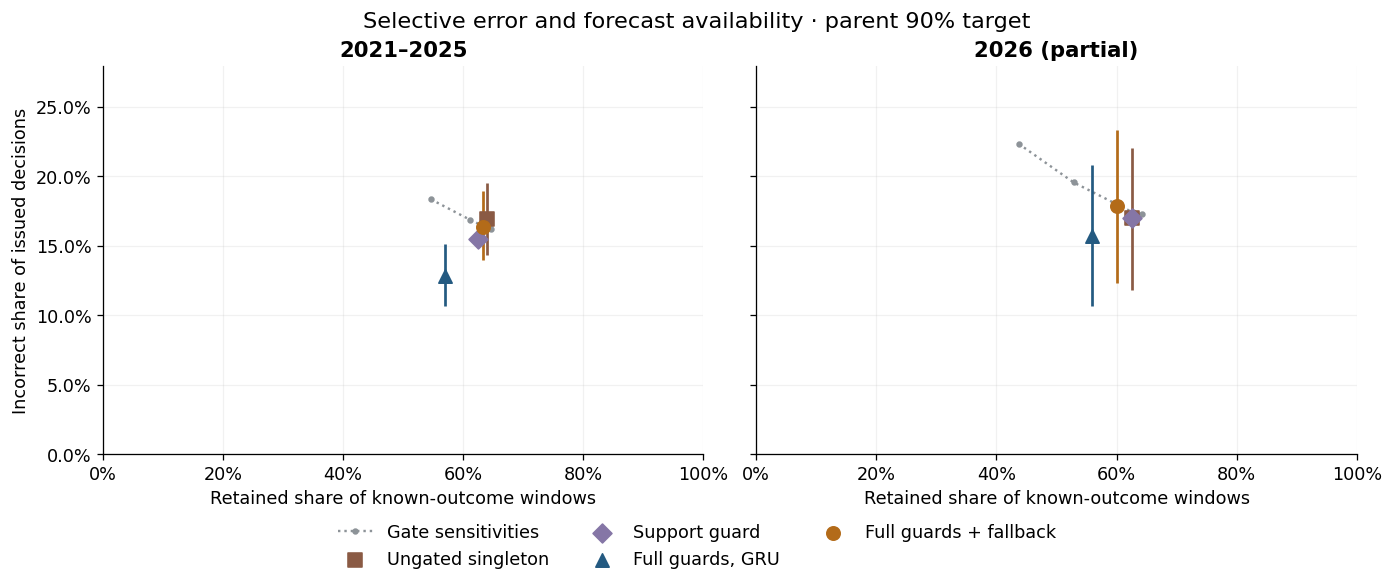

In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,5),sharex=True,sharey=True,layout='constrained')
styles={'gru_singleton':('Ungated singleton','#8A5A44','s'),'supported_gru':('Support guard','#8576A6','D'),'guarded_gru':('Full guards, GRU','#245A81','^'),'guarded_fallback':('Full guards + fallback','#B36B19','o')}
for ax,role in zip(axes,['retrospective_cycle25','supplementary_2026']):
    table=metrics[metrics.role.eq(role)&metrics.alpha.eq(.1)]
    sens=table[~table.policy.isin(main)].sort_values('retention')
    ax.plot(sens.retention,sens.selective_error,color='#8D9398',ls=':',marker='.',label='Gate sensitivities')
    for name,(label,color,marker) in styles.items():
        row=table[table.policy.eq(name)].iloc[0]
        bounds=intervals[intervals.role.eq(role)&intervals.policy.eq(name)&intervals.alpha.eq(.1)&intervals.grouping.eq('region_component')&intervals.metric.eq('selective_error')]
        ax.scatter(row.retention,row.selective_error,color=color,marker=marker,s=70,label=label,zorder=3)
        if len(bounds) and bounds[['low','high']].notna().all(axis=None):
            lo,hi=bounds.iloc[0][['low','high']];ax.vlines(row.retention,lo,hi,color=color,lw=1.7)
    ax.set(title=PERIODS[role],xlabel='Retained share of known-outcome windows',xlim=(0,1),ylim=(0,max(.12,metrics.selective_error.max()*1.25)))
    ax.xaxis.set_major_formatter(PercentFormatter(1));ax.yaxis.set_major_formatter(PercentFormatter(1));ax.grid(alpha=.17)
axes[0].set_ylabel('Incorrect share of issued decisions')
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside lower center',ncol=3,frameon=False)
fig.suptitle('Selective error and forecast availability · parent 90% target',fontsize=14)
fig.savefig(OUTPUT_DIR/'risk_retention.png',bbox_inches='tight');plt.show()

### 8. What happens to all flare windows?
These bars sum to 100% of actual flare windows in each matched evaluation period. Deferrals are kept separate from incorrect no-flare decisions; neither is a successful flare alert.

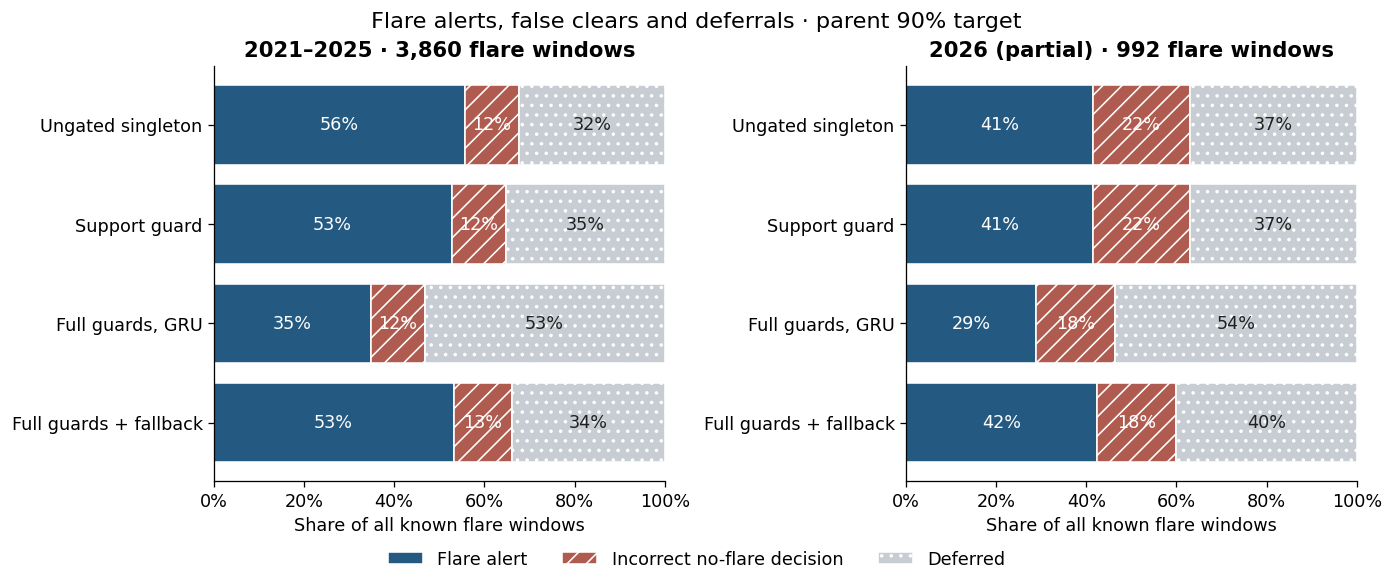

In [9]:
fig,axes=plt.subplots(1,2,figsize=(12,5),sharex=True,layout='constrained')
parts=[('alert_fraction_of_all_flares','Flare alert','#245A81',''),('false_clear_fraction_of_all_flares','Incorrect no-flare decision','#B05B4F','//'),('deferred_fraction_of_all_flares','Deferred','#C7CDD2','..')]
for ax,role in zip(axes,['retrospective_cycle25','supplementary_2026']):
    table=metrics[metrics.role.eq(role)&metrics.alpha.eq(.1)].set_index('policy').loc[main];left=np.zeros(len(table))
    for field,label,color,hatch in parts:
        values=table[field].to_numpy();ax.barh(range(len(table)),values,left=left,color=color,hatch=hatch,edgecolor='white',label=label)
        for i,v in enumerate(values):
            if v>.07:ax.text(left[i]+v/2,i,f'{v:.0%}',ha='center',va='center',color='white' if field!='deferred_fraction_of_all_flares' else '#202020')
        left+=values
    ax.set(yticks=range(len(table)),yticklabels=[styles[n][0] for n in main],title=f'{PERIODS[role]} · {int(table.flare_cases.iloc[0]):,} flare windows',xlim=(0,1),xlabel='Share of all known flare windows');ax.invert_yaxis();ax.xaxis.set_major_formatter(PercentFormatter(1))
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside lower center',ncol=3,frameon=False)
fig.suptitle('Flare alerts, false clears and deferrals · parent 90% target',fontsize=14)
fig.savefig(OUTPUT_DIR/'flare_outcomes.png',bbox_inches='tight');plt.show()

### 9. Candidate states across the entire calendar population
These denominators include missing inputs, unknown outcomes and year-boundary cases. They differ from the performance tables. The state names are experimental; source-level quality and actual delivery remain unverified.

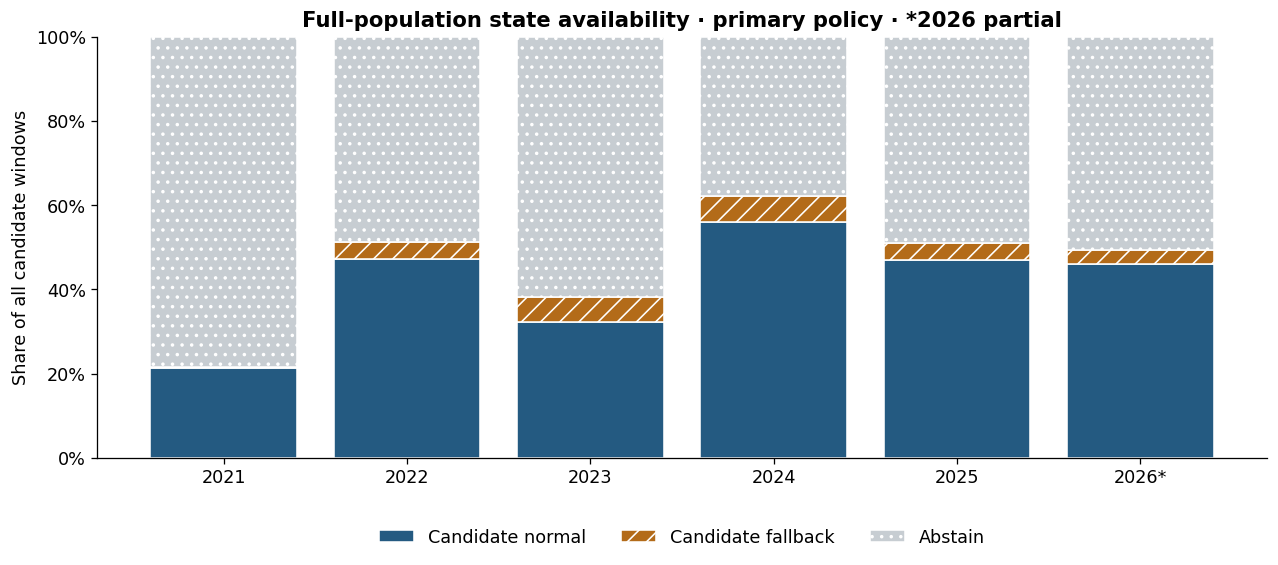

,year,population_cases,missing_inputs,normal,degraded,abstain,issued_unknown_outcomes,known_flares,deferred_known_flares
0,2021,5828,1253,1249,14,4565,62,229,163
1,2022,11535,2525,5438,469,5628,841,854,378
2,2023,14676,3489,4740,864,9072,855,1384,706
3,2024,14732,3359,8267,901,5564,3552,1713,703
4,2025,14774,5516,6934,607,7233,1480,1076,750
5,2026,14923,2764,6864,509,7550,697,1208,613


In [10]:
fig,ax=plt.subplots(figsize=(11,4.8),layout='constrained')
table=availability[availability.alpha.eq(.1)].sort_values('year');bottom=np.zeros(len(table))
for field,label,color,hatch in [('normal','Candidate normal','#245A81',''),('degraded','Candidate fallback','#B36B19','//'),('abstain','Abstain','#C7CDD2','..')]:
    values=table[field]/table.population_cases
    ax.bar(table.year.astype(str).replace('2026','2026*'),values,bottom=bottom,color=color,hatch=hatch,edgecolor='white',label=label);bottom+=values
ax.set(ylim=(0,1),ylabel='Share of all candidate windows',title='Full-population state availability · primary policy · *2026 partial')
ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(loc='upper center',bbox_to_anchor=(.5,-.13),ncol=3,frameon=False)
fig.savefig(OUTPUT_DIR/'population_states.png',bbox_inches='tight');plt.show()
display(table[['year','population_cases','missing_inputs','normal','degraded','abstain','issued_unknown_outcomes','known_flares','deferred_known_flares']].reset_index(drop=True))

### 10. Fallback errors and reasons for withholding forecasts
The fallback is evaluated separately. A low aggregate error can reflect a predominance of quiet windows; retain the flare counts and errors in view. Reason counts use precedence so each case has one main explanation; the full output also saves overlapping primary flags.

In [11]:
table=states[states.policy.eq(CONFIG['primary_policy'])&states.alpha.eq(.1)&states.role.ne('policy_validation')].copy()
table['Period']=table.role.map(PERIODS)
display(table[['Period','state','cases','flare_cases','issued','errors','selective_error','true_alerts','false_clears','deferred_flares']].round(4).reset_index(drop=True))
display(reasons[reasons.alpha.eq(.1)&reasons.role.ne('policy_validation')][['role','reason','cases','flare_cases']].reset_index(drop=True))
display(intervals[intervals.policy.eq(CONFIG['primary_policy'])&intervals.alpha.eq(.1)&intervals.role.ne('policy_validation')&intervals.metric.isin(['selective_error','false_clear_fraction_of_all_flares','deferred_fraction_of_all_flares'])][['role','grouping','metric','low','high']].round(4).reset_index(drop=True))

,Period,state,cases,flare_cases,issued,errors,selective_error,true_alerts,false_clears,deferred_flares
0,2021–2025,normal,20435,1804,20435,2618,0.1281,1345,459,0
1,2021–2025,degraded,2233,752,2233,1098,0.4917,707,45,0
2,2021–2025,abstain,13178,1304,0,0,NaN,0,0,1304
3,2026 (partial),normal,6208,461,6208,977,0.1574,287,174,0
4,2026 (partial),degraded,468,134,468,217,0.4637,133,1,0
5,2026 (partial),abstain,4442,397,0,0,NaN,0,0,397


,role,reason,cases,flare_cases
0,retrospective_cycle25,ambiguous_gru_set,9264,1071
1,retrospective_cycle25,checks_passed,20435,1804
2,retrospective_cycle25,conflicting_singletons,3,0
3,retrospective_cycle25,empty_gru_set,29,3
4,retrospective_cycle25,feature_distance_flag,442,9
5,retrospective_cycle25,insufficient_calibration_support,3112,119
6,retrospective_cycle25,logistic_fallback_candidate,2233,752
7,retrospective_cycle25,seed_disagreement,328,102
8,supplementary_2026,ambiguous_gru_set,3930,345
9,supplementary_2026,checks_passed,6208,461


,role,grouping,metric,low,high
0,retrospective_cycle25,region_component,selective_error,0.1402,0.1895
1,retrospective_cycle25,region_component,false_clear_fraction_of_all_flares,0.0867,0.1769
2,retrospective_cycle25,region_component,deferred_fraction_of_all_flares,0.2754,0.3993
3,retrospective_cycle25,calendar_7day_UTC,selective_error,0.1387,0.1871
4,retrospective_cycle25,calendar_7day_UTC,false_clear_fraction_of_all_flares,0.0848,0.1762
5,retrospective_cycle25,calendar_7day_UTC,deferred_fraction_of_all_flares,0.2830,0.3963
6,supplementary_2026,region_component,selective_error,0.1237,0.2332
7,supplementary_2026,region_component,false_clear_fraction_of_all_flares,0.0852,0.2872
8,supplementary_2026,region_component,deferred_fraction_of_all_flares,0.2513,0.5760
9,supplementary_2026,calendar_7day_UTC,selective_error,0.1208,0.2331


## Takeaways

**Decision from this experiment:** retain the logistic fallback as a documented negative candidate; do not promote it to an approved degraded mode. The guarded GRU also remains experimental: reduced aggregate error comes with substantial loss of useful flare alerts. No acceptable operational risk target has been established, and comparisons are retrospective with provisional labels.

In [12]:
messages=[]
for role in ['retrospective_cycle25','supplementary_2026']:
    rows=metrics[metrics.role.eq(role)&metrics.alpha.eq(.1)].set_index('policy')
    base=rows.loc['gru_singleton'];chosen=rows.loc[CONFIG['primary_policy']]
    messages.append(f'**{PERIODS[role]}:** primary candidate retains **{chosen.retention:.1%}** of evaluated windows (ungated singletons: {base.retention:.1%}); errors among issued decisions are **{chosen.selective_error:.1%}** (ungated: {base.selective_error:.1%}).')
    messages.append(f'Of all flare windows, **{chosen.alert_fraction_of_all_flares:.1%}** receive a flare alert, **{chosen.false_clear_fraction_of_all_flares:.1%}** an incorrect no-flare decision, and **{chosen.deferred_fraction_of_all_flares:.1%}** are deferred.')
display(Markdown('\n\n'.join(messages)))
display(Markdown('### Limits on interpretation\n'+'\n'.join('- '+s for s in summary['limitations'])))
for name,expected in summary['output_sha256'].items():assert sha256(OUTPUT_DIR/name)==expected,name
print('Frozen artifacts verified; operationally validated: False')

**2021–2025:** primary candidate retains **63.2%** of evaluated windows (ungated singletons: 63.9%); errors among issued decisions are **16.4%** (ungated: 16.9%).

Of all flare windows, **53.2%** receive a flare alert, **13.1%** an incorrect no-flare decision, and **33.8%** are deferred.

**2026 (partial):** primary candidate retains **60.0%** of evaluated windows (ungated singletons: 62.6%); errors among issued decisions are **17.9%** (ungated: 17.0%).

Of all flare windows, **42.3%** receive a flare alert, **17.6%** an incorrect no-flare decision, and **40.0%** are deferred.

### Limits on interpretation
- Normal and degraded are experimental state names, not certifications of safe or calibrated forecasts. The logistic fallback is a candidate evaluated here, not an approved operational mode.
- The q99 distance and q95 spread gates are declared heuristics; no acceptable operational error target or cost ratio has been supplied. Gates are not selected from later outcomes.
- Feature distance uses a unimodal covariance summary and is an outlier flag, not a validated OOD detector. Seed disagreement comes from only three same-architecture runs and is not a calibrated uncertainty interval.
- Training and January-June 2014 reference data were already used for model fitting and early stopping. The earlier 2015-2019 block already selected rolling windows; its policy metrics are development reuse, not independent validation.
- Later datasets have already been inspected. Candidate labels, unresolved associations, historical availability and continuous outcome coverage remain provisional. No source-level HMI quality flag or delivery-delay reconstruction is added here.
- Rolling sets use delayed earlier evaluation-period labels under the parent protocol. Threshold updates remain daily, forecasts use inherited native cases, and overlapping windows are not independent flare events.
- Classwise errors and deferrals must accompany aggregate selective error. Abstention is neither a correct forecast nor a no-flare decision; deferred flares are reported separately.
- Bootstrap intervals condition on realized decisions and do not repeat sequential adaptation, fit gates, or include label, model, calibration or selection uncertainty.
- Matched-known-outcome performance and full calendar-population availability have different denominators. Availability includes unknown and boundary cases that are excluded from inherited performance roles.
- Both modes require the same SHARP inputs: the logistic fallback does not repair missing SHARP or feature-distance flags. AIA fusion, correlated-outage replay and prospective evaluation remain future experiments.

Frozen artifacts verified; operationally validated: False


**Next scientific decision:** assess whether the reduction in incorrect decisive forecasts justifies the loss of useful flare alerts and the extra fallback errors. Operational cost and escalation requirements should be agreed before declaring an acceptable policy. Further tuning reuses already inspected evidence and needs a fresh future evaluation for confirmation.

**Reusable outputs:** state and reason per case, frozen reference limits and distance estimator, all declared policy comparisons, classwise denominators, annual summaries, two conditional resampling sensitivities, source hashes and executed code. Full per-case files remain local; compact results and this executed notebook are versioned.